# 07. Final model, test set evaluation


## Contents

1. Summary
2. Setup
3. Data preparation
4. Final model and test evaluation
5. Stratified error analysis
6. Per-vessel analysis
7. Conditional uncertainty radius
8. Conclusion

## 1. Summary

**Context**
- NB06 fixed the feature set and hyperparameters.
- Those choices are fit once here on the full trainval set and evaluated once on the held-out test set. No tuning or feature change follows from what is found here.

**Objective**
- Confirm that the OOF gains hold on untouched test vessels.
- Stratify error by regime and vessel.
- Test whether a pooled R90 stays usable once error is stratified, and whether conditioning on effective speed fixes coverage.

**Outcome**
- LGBM is better than the constant-velocity baseline at every horizon from 2h to 72h on MAE and on R90; search-area reduction grows from **60.5%** at 2h to **81.5%** at 72h.
- On pooled R50 the baseline leads through most horizons; LGBM leads R50 only on maneuvering tracks (section 5).
- The OOF to test gap stays under about **3.2%** on MAE and about **5.3%** on R90, in the same range as the baseline's own sampling drift.
- Stratified gain is uneven: roughly half the fleet is stationary or near-stationary, where the baseline is already close to exact; the model's advantage concentrates on maneuvering vessels and on the error tail. Per-vessel difficulty is persistent across horizons and tracks typical operating speed.
- Conditioning R90 on effective speed corrects a **26** point coverage gap between slow and fast vessels at 2h; the correction is incomplete at long horizons, where coverage stays a few points under the announced 90%.


## 2. Setup

The test set has been held out since NB02 and is read once, here. Features, lookback, lag count, model class and hyperparameters were all fixed in NB06. Nothing is revised on the basis of what this notebook shows.

In [1]:
import gc
import time
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor
from scipy.stats import spearmanr

from vessel_tracker.config import settings
from vessel_tracker.paths import DATA_PROCESSED
from vessel_tracker.preprocessing import vessel_train_test_split
from vessel_tracker.metrics import haversine_distance

# --- Load cleaned + resampled dataset (NB02) ---
processed_path = DATA_PROCESSED / f"AIS_clean_resampled_{settings.resample_interval_min}min.parquet"
df = pd.read_parquet(processed_path)
df["BaseDateTime"] = pd.to_datetime(df["BaseDateTime"])
print(f"Loaded: {len(df):,} rows, {df['MMSI'].nunique():,} vessels")

# --- Replay the split (same seed, same partition as NB02) ---
df_train, df_val, df_test, *_ = vessel_train_test_split(df)
print(f"Train: {df_train['MMSI'].nunique():,} vessels | "
      f"Val: {df_val['MMSI'].nunique():,} | Test: {df_test['MMSI'].nunique():,}")
df_trainval = pd.concat([df_train, df_val], axis=0)
print(f"Test set: {len(df_test):,} rows, {df_test['MMSI'].nunique():,} vessels")

Loaded: 3,661,057 rows, 2,173 vessels
Train: 1,521 vessels | Val: 326 | Test: 326
Test set: 541,937 rows, 326 vessels


### 2.1 Helpers

Copied verbatim from NB06: `create_lag_features`, `create_dx_dy`, `create_effective_speed`, `create_target`, `compute_metrics`.

Two functions are copied with their body unchanged and renamed. `evaluate_model_fold` becomes `fit_predict` and `evaluate_baseline_fold` becomes `predict_baseline`. This is to avoid confusion as there is no crossvalidation here. 

`create_path_and_straightness` is new. It computes the path length and the straightness of the past lookback window, vectorised over the whole frame. 

In [2]:
def create_lag_features(df, nb_lags: int, lookback_minutes: int):
    """
    Add evenly spaced lag features (LAT_lag_i, LON_lag_i) for each vessel.

    Parameters:
    -----------
    df : DataFrame
        Must contain MMSI, LAT, LON.
    nb_lags : int
        Number of lag columns to generate (2 to available_lags).
    lookback_minutes : int
        Lookback duration in minutes, converted to steps via settings.resample_interval_min.

    Returns:
    --------
    DataFrame
        Same rows minus warm-up rows without a full lookback. LAT/LON are replaced
        by LAT_lag_i / LON_lag_i columns (lag 0 is the current position).
    """
    lookback_steps = lookback_minutes // settings.resample_interval_min
    available_lags = lookback_steps + 1
    #check if there are enough time steps for the number of lags required
    if not (2 <= nb_lags <= available_lags):
        raise ValueError(f"nb_of_lags={nb_lags} does not fit lookback_steps={lookback_steps}: "
            f"expected 1..{available_lags}.")

    #generate lags evenly spaced

    lags = np.unique(np.linspace(0, lookback_steps, nb_lags).round().astype(int))
    if len(lags) != nb_lags:
        raise ValueError(
            f"rounding over a {lookback_steps}-step window reduced the number of lags"
            f"number of lags asked : {nb_lags} number of lags obtained: {len(lags)}"

        )


    vessels  = df.groupby("MMSI")

    lag_col = {f"{coord}_lag_{lag}": vessels[coord].shift(lag)
               for lag in lags
               for coord in ("LAT", "LON")
               }
    df = df.assign(**lag_col).drop(columns= ["LAT", "LON"]).dropna(axis= 0)
    return df

In [3]:
def create_dx_dy(df, lookback_minutes: int):
    """Net displacement over lookback from lag features (east/north in degrees).

    Input: df with LAT_lag_0, LON_lag_0, LAT_lag_{lookback}, LON_lag_{lookback}.
    Output: same df with dx = LON_now - LON_old, dy = LAT_now - LAT_old.
    No groupby: each row already carries its own lags.
    """
    lookback_steps = lookback_minutes // settings.resample_interval_min
    required_cols = [
        "LAT_lag_0", "LON_lag_0",
        f"LAT_lag_{lookback_steps}", f"LON_lag_{lookback_steps}",
    ]

    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in dataframe: {missing}")

    return df.assign(
        dx=df["LON_lag_0"] - df[f"LON_lag_{lookback_steps}"],
        dy=df["LAT_lag_0"] - df[f"LAT_lag_{lookback_steps}"],
    )

In [4]:
def create_effective_speed(df, lookback_minutes: int):
    """Speed along actual path, not birdeyes path,  in knots. 

    Input: df with MMSI, LAT, LON (sorted by MMSI, time); lookback_minutes.
    Output: same df with effective_speed_knots.
    First lookback_steps rows per MMSI have NaN (no dropna).
    """
    lookback_steps = lookback_minutes // settings.resample_interval_min

    vessels = df.groupby("MMSI")
    # shift via groupby MMSI → Series aligned on df, NaN on the first row of each vessel
    lat_prev = vessels["LAT"].shift(1)
    lon_prev = vessels["LON"].shift(1)
    # haversine wants Series/arrays, not a SeriesGroupBy → df["LAT"], not vessels["LAT"]
    step_km = haversine_distance(lat_prev, lon_prev, df["LAT"], df["LON"])

    # step_km is a flat Series: re-group by MMSI for the rolling (same index as df)
    path_km = (
        step_km.groupby(df["MMSI"], sort=False)
        .rolling(lookback_steps, min_periods=lookback_steps)
        .sum()
        .reset_index(level=0, drop=True)
    )

    effective_speed_knots = (path_km / 1.852) / (lookback_minutes / 60)

    return df.assign(effective_speed_knots=effective_speed_knots)


In [5]:
def create_target(df: pd.DataFrame, horizon_grid_minutes: list[int]):

    """
    Build a long-format DataFrame of velocity targets for a list of prediction horizons.

    Parameters:
    -----------
    df : DataFrame
        Must already contain lag features, including LAT_lag_0 and LON_lag_0
        (current position) and columns MMSI, BaseDateTime.
    horizon_grid_minutes : list[int]
        Requested prediction horizons in minutes. Rounded to the nearest multiple
        of settings.resample_interval_min, deduplicated, and horizons rounding to
        0 are dropped. Raises ValueError if none remain.

    Returns:
    --------
    DataFrame
        One row per (source row, usable horizon). Added columns:
        vx, vy (deg/min velocity targets), h (effective horizon in minutes).
        Rows without a future position (end of track) are dropped.
    """
    horizons = np.asarray(horizon_grid_minutes)
    h_steps = np.unique(np.round(horizons / settings.resample_interval_min)).astype(int)
    h_steps = h_steps[h_steps > 0]
    if len(h_steps) == 0:
        raise ValueError("no prediction horizon > 0")

    required_cols = ["MMSI", "BaseDateTime", "LAT_lag_0", "LON_lag_0"]
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df = df.sort_values(by=["MMSI", "BaseDateTime"]).reset_index(drop=True)

    lat0 = df["LAT_lag_0"].to_numpy()
    lon0 = df["LON_lag_0"].to_numpy()
    grp = df.groupby("MMSI")

    target_parts = []
    for h_step in h_steps:
        lat_fut = grp["LAT_lag_0"].shift(-h_step).to_numpy()
        lon_fut = grp["LON_lag_0"].shift(-h_step).to_numpy()
        dt = int(h_step * settings.resample_interval_min) #cast as int to avoid upcast to float64
        target_parts.append(pd.DataFrame({
            "row_id": np.arange(len(df), dtype=np.int64),
            "vx": (lon_fut - lon0) / dt,
            "vy": (lat_fut - lat0) / dt,
            "h": np.int16(dt),
        }))

    targets = pd.concat(target_parts, ignore_index=True).dropna(subset=["vx", "vy"])

    df_out = df.iloc[targets["row_id"].to_numpy()].reset_index(drop=True)
    df_out["vx"] = targets["vx"].to_numpy()
    df_out["vy"] = targets["vy"].to_numpy()
    df_out["h"] = targets["h"].to_numpy()
    return df_out


In [6]:
def compute_metrics(oof_df):
    """
    Aggregate the per-row haversine error (already computed by run_crossval) into
    per-(model_name, h) metrics.

    Parameters:
    -----------
    oof_df : DataFrame
        Output of run_crossval. Must contain model_name, h, error_km.

    Returns:
    --------
    DataFrame
        One row per (model_name, h). Columns:
        model_name, h, mae_mean, r50_km, r80_km, r90_km, r95_km.
    """
    rows = []

    # mae and R(h,p) must be calculated by horizon, so we need to groupby
    for (name, h), horizon_subset in oof_df.groupby(["model_name", "h"]):
        r50, r80, r90, r95 = np.percentile(horizon_subset["error_km"], [50, 80, 90, 95])
        rows.append({
            "model_name": name,
            "h": h,
            "mae_mean": float(horizon_subset["error_km"].mean()),
            "r50_km": float(r50),
            "r80_km": float(r80),
            "r90_km": float(r90),
            "r95_km": float(r95),
        })

    return pd.DataFrame(
        rows, columns=["model_name", "h", "mae_mean", "r50_km", "r80_km", "r90_km", "r95_km"]
    )

In [7]:
def fit_predict(X_train, y_train, X_pred, estimator):
    """
    Fit estimator on the training arrays, predict velocity (vx, vy) on X_pred.

    Parameters:
    -----------
    X_train, y_train : DataFrame
        Training features and targets, y_train columns [vx, vy].
    X_pred : DataFrame
        Features to predict on.
    estimator : sklearn estimator
        Base estimator, wrapped in MultiOutputRegressor internally.

    Returns:
    --------
    dict
        vx_pred : ndarray, shape (n_pred,), predicted longitude velocity (deg/min)
        vy_pred : ndarray, shape (n_pred,), predicted latitude velocity (deg/min)
        fit_time_s : float, wall-clock seconds for model.fit
        inference_time_s : float, wall-clock seconds for model.predict
    """
    model = MultiOutputRegressor(estimator=estimator)
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    fit_time_s = time.perf_counter() - t0

    t0 = time.perf_counter()
    y_pred = model.predict(X_pred)
    inference_time_s = time.perf_counter() - t0

    return {
        "vx_pred": y_pred[:, 0],
        "vy_pred": y_pred[:, 1],
        "fit_time_s": fit_time_s,
        "inference_time_s": inference_time_s,
    }

In [8]:
def predict_baseline(X_pred, lookback_minutes):
    """
    Compute baseline (constant-velocity extrapolation) predicted velocity on X_pred.

    Extrapolates from lag_0 (current position) and lag_lookback_steps (oldest
    lookback position), expressed as a velocity in deg/minute (same unit as vx, vy).

    Parameters:
    -----------
    X_pred : DataFrame
        Features to predict on. Must contain LAT_lag_0, LON_lag_0,
        LAT_lag_{lookback_steps}, LON_lag_{lookback_steps}.
    lookback_minutes : int
        Lookback duration in minutes.

    Returns:
    --------
    dict
        vx_pred : ndarray, shape (n_pred,), extrapolated longitude velocity (deg/min)
        vy_pred : ndarray, shape (n_pred,), extrapolated latitude velocity (deg/min)
        inference_time_s : float, wall-clock seconds for the extrapolation computation
    """
    lookback_steps = lookback_minutes // settings.resample_interval_min

    required_cols = [
        "LAT_lag_0", "LON_lag_0",
        f"LAT_lag_{lookback_steps}", f"LON_lag_{lookback_steps}",
    ]
    missing = [col for col in required_cols if col not in X_pred.columns]
    if missing:
        raise ValueError(f"Missing required columns in X_pred: {missing}")

    t0 = time.perf_counter()

    LAT_now = X_pred["LAT_lag_0"]
    LON_now = X_pred["LON_lag_0"]
    LAT_old = X_pred[f"LAT_lag_{lookback_steps}"]
    LON_old = X_pred[f"LON_lag_{lookback_steps}"]

    vy_pred = (LAT_now - LAT_old) / lookback_minutes
    vx_pred = (LON_now - LON_old) / lookback_minutes

    inference_time_s = time.perf_counter() - t0

    return {
        "vx_pred": vx_pred.to_numpy(),
        "vy_pred": vy_pred.to_numpy(),
        "inference_time_s": inference_time_s,
    }

In [9]:
def create_path_and_straightness(df, lookback_minutes: int):
    """Path length and straightness of the past lookback window, per vessel.

    path_length_km sums the distance between consecutive resampled points.
    straightness is the net displacement divided by that path length, so 1 is a
    perfectly straight run and values near 0 mean the vessel wandered or held
    position. Both are diagnostic variables used to slice results in sections 5
    and 6, they are never model features.

    Parameters
    ----------
    df : DataFrame
        Sorted by MMSI then BaseDateTime, with raw LAT and LON.
    lookback_minutes : int
        Width of the window, converted to steps with settings.resample_interval_min.

    Returns
    -------
    DataFrame
        Same frame with path_length_km and straightness. The first lookback_steps
        rows of each vessel are NaN, no dropna here.
    """
    steps = lookback_minutes // settings.resample_interval_min
    grouped = df.groupby("MMSI", sort=False)

    lat_prev = grouped["LAT"].shift(1)
    lon_prev = grouped["LON"].shift(1)
    step_km = haversine_distance(
        lat_prev.to_numpy(), lon_prev.to_numpy(),
        df["LAT"].to_numpy(), df["LON"].to_numpy(),
    ) #returns a np array
    step_km = pd.Series(step_km, index=df.index).fillna(0.0)

    path_length_km = (
        step_km.groupby(df["MMSI"], sort=False)
        .rolling(steps, min_periods=steps)
        .sum()
        .reset_index(level=0, drop=True)
    ) #sum the actual distance travelled for each lookback window (grouped by MMSI)

    lat_start = grouped["LAT"].shift(steps)
    lon_start = grouped["LON"].shift(steps)
    net_km = haversine_distance(
        lat_start.to_numpy(), lon_start.to_numpy(),
        df["LAT"].to_numpy(), df["LON"].to_numpy(),
    )


    straightness = np.divide(
        net_km, path_length_km.to_numpy(),
        out=np.full(len(df), np.nan), #prefill a np array of length len(df) with nan
        where=path_length_km.to_numpy() > 0, #fill the straightness where it exists
    ) #cases where denominator = 0 and straightness = inf are set to NaN 
    return df.assign(path_length_km=path_length_km, straightness=straightness)

## 3. Data preparation

The pipeline order is imposed by `create_lag_features`, which drops raw LAT and LON. Features reading raw positions run before it, features reading the lags run after it, and the target comes last since it is built from `LAT_lag_0` and `LON_lag_0`.

`effective_speed_knots`, `straightness` and `path_length_km` are computed here but do not appear in the feature list. They will be used for stratified analysis in sections 5 and 6. 

In [10]:
lookback = 12
nb_lags = 6
horizons_hours = [2, 6, 8, 10, 12, 24, 48, 72]
horizon_grid_minutes = [h * 60 for h in horizons_hours]

def build_long_dataset(df):
    """Apply the retained NB06 pipeline plus the two diagnostic columns.

    Returns one row per observation and horizon, with the velocity target.
    """
    out = df.sort_values(["MMSI", "BaseDateTime"])
    out = create_effective_speed(out, lookback_minutes=lookback * 60)
    out = create_path_and_straightness(out, lookback_minutes=lookback * 60)
    out = create_lag_features(out, nb_lags=nb_lags, lookback_minutes=lookback * 60)
    out = create_dx_dy(out, lookback_minutes=lookback * 60)
    out = create_target(out, horizon_grid_minutes=horizon_grid_minutes)
    return out.dropna(axis=0).reset_index(drop=True)

trainval_long = build_long_dataset(df_trainval)
print(f"trainval: {len(trainval_long):,} rows, {trainval_long['MMSI'].nunique():,} vessels")

test_long = build_long_dataset(df_test)
print(f"test:     {len(test_long):,} rows, {test_long['MMSI'].nunique():,} vessels")

_ = gc.collect()


trainval: 22,114,272 rows, 1,756 vessels
test:     3,832,949 rows, 304 vessels


In [11]:
# Retained set from NB06 section 4.5, lags_dxdy_geom.
# Lag names come from create_lag_features (already on trainval_long).
lag_cols = [c for c in trainval_long.columns if c.startswith(("LAT_lag", "LON_lag"))]
final_feature_cols = lag_cols + ["dx", "dy", "Length", "Width", "Draft", "h"]
print(f"final feature set ({len(final_feature_cols)}): {final_feature_cols}")


final feature set (18): ['LAT_lag_0', 'LON_lag_0', 'LAT_lag_14', 'LON_lag_14', 'LAT_lag_29', 'LON_lag_29', 'LAT_lag_43', 'LON_lag_43', 'LAT_lag_58', 'LON_lag_58', 'LAT_lag_72', 'LON_lag_72', 'dx', 'dy', 'Length', 'Width', 'Draft', 'h']


## 4. Final model and test evaluation

One fit on the full trainval set, one prediction on the test set, and the baseline evaluated on the same rows.

Results are held in a single wide frame: one row per observation, with both predictors in columns. The interest of the wide format here is to have all the data relative to one observation on the same row. 

In [12]:
FORCE_RECOMPUTE = False  # set True to refit even if cached output exists
out_dir = Path("outputs")
results_path = out_dir / "test_results_final.parquet"

if not FORCE_RECOMPUTE and results_path.exists():
    print("Cached test results found, loading from disk (set FORCE_RECOMPUTE=True to refit).")
    results = pd.read_parquet(results_path)
else:
    final_model = LGBMRegressor(verbose=-1, random_state=settings.random_seed)

    X_trainval = trainval_long[final_feature_cols]
    y_trainval = trainval_long[["vx", "vy"]]
    X_test = test_long[final_feature_cols]

    model_out = fit_predict(X_trainval, y_trainval, X_test, final_model)
    baseline_out = predict_baseline(X_test, lookback_minutes=lookback * 60)

    print(f"fit: {model_out['fit_time_s']:.1f}s | "
          f"model inference: {model_out['inference_time_s']:.1f}s | "
          f"baseline inference: {baseline_out['inference_time_s']:.1f}s")

    results = test_long[[
        "MMSI", "h", "LAT_lag_0", "LON_lag_0", "vx", "vy",
        "effective_speed_knots", "straightness", "path_length_km",
    ]].copy()
    results = results.rename(columns={"vx": "vx_true", "vy": "vy_true"})
    results["horizon_hours"] = (results["h"] / 60).round().astype(int)

    # numpy arrays assign by position, and results keeps test_long's row order
    results["vx_lgbm"] = model_out["vx_pred"]
    results["vy_lgbm"] = model_out["vy_pred"]
    results["vx_baseline"] = baseline_out["vx_pred"]
    results["vy_baseline"] = baseline_out["vy_pred"]

    # reconstruction of future LAT and LON
    for source in ("true", "lgbm", "baseline"):
        results[f"LON_{source}"] = results["LON_lag_0"] + results[f"vx_{source}"] * results["h"]
        results[f"LAT_{source}"] = results["LAT_lag_0"] + results[f"vy_{source}"] * results["h"]

    # compute haversine error for LAT/LON pred
    for source in ("lgbm", "baseline"):
        results[f"error_km_{source}"] = haversine_distance(
            results["LAT_true"].to_numpy(), results["LON_true"].to_numpy(),
            results[f"LAT_{source}"].to_numpy(), results[f"LON_{source}"].to_numpy(),
        )

    results.to_parquet(results_path, index=False)

print(f"results: {len(results):,} rows, {results.shape[1]} columns")
results.head()


Cached test results found, loading from disk (set FORCE_RECOMPUTE=True to refit).
results: 3,832,949 rows, 22 columns


,MMSI,h,LAT_lag_0,LON_lag_0,vx_true,vy_true,effective_speed_knots,straightness,path_length_km,horizon_hours,...,vx_baseline,vy_baseline,LON_true,LAT_true,LON_lgbm,LAT_lgbm,LON_baseline,LAT_baseline,error_km_lgbm,error_km_baseline
0,205685000,120,29.28327,-94.53872,-0.000002,0.000003,0.050567,0.065780,1.123801,2,...,2.222222e-07,-9.027778e-07,-94.53898,29.28358,-94.543315,29.285484,-94.538693,29.283162,0.470704,0.054192
1,205685000,120,29.28322,-94.53867,-0.000004,0.000004,0.050506,0.074032,1.122450,2,...,4.166667e-07,-9.722222e-07,-94.53910,29.28372,-94.543265,29.285434,-94.538620,29.283103,0.446623,0.082880
2,205685000,120,29.28317,-94.53862,-0.000003,0.000003,0.049297,0.051257,1.095576,2,...,2.500000e-07,-6.666667e-07,-94.53898,29.28355,-94.543215,29.285384,-94.538590,29.283090,0.458548,0.063616
3,205685000,120,29.28325,-94.53872,-0.000002,0.000003,0.048948,0.025940,1.087827,2,...,-6.944444e-08,-3.472222e-07,-94.53902,29.28363,-94.543315,29.285464,-94.538728,29.283208,0.463767,0.054759
4,205685000,120,29.28328,-94.53878,-0.000002,0.000002,0.048508,0.035081,1.078039,2,...,-1.388889e-08,-4.722222e-07,-94.53902,29.28358,-94.543375,29.285494,-94.538782,29.283223,0.472936,0.045904


### 4.1 Metrics by horizon

`compute_metrics` is reused unchanged from NB06, which means it expects one row per observation and predictor. `results` is reshaped to that layout for the call and the wide frame stays the reference everywhere else. Reusing the function rather than rewriting the computation keeps the percentile convention identical to the out of fold numbers compared in 4.2.

In [13]:
# reshaping df from wide to long
# columns "error_km_lgbm", "error_km_baseline" will be stacked vertically
#h will remain the same and will be duplicated
metrics_input = results.melt(
    id_vars=["h"],
    value_vars=["error_km_lgbm", "error_km_baseline"], #columns that will be stacked
    var_name="model_name",  
    value_name="error_km",
)
metrics_input["model_name"] = metrics_input["model_name"].str.replace("error_km_", "", regex=False) #remove the erro_km prefix coming from former column

summary_test = compute_metrics(metrics_input)
summary_test["horizon_hours"] = (summary_test["h"] / 60).round().astype(int)
summary_test.to_csv(Path("outputs") / "test_summary_final.csv", index=False)

del metrics_input
_ = gc.collect()

def pivot_test(metric):
    """One row per horizon, one column per predictor, for a single metric."""
    return (
        summary_test.pivot_table(index="horizon_hours", columns="model_name", values=metric)
        .reindex(columns=["baseline", "lgbm"])
        .sort_index()
    )

mae_test = pivot_test("mae_mean").round(2)
r50_test = pivot_test("r50_km").round(2)
r90_test = pivot_test("r90_km").round(2)
area_reduction_pct = ((1 - (r90_test["lgbm"] / r90_test["baseline"]) ** 2) * 100).round(1)

print("MAE (km):")
display(mae_test)
print("R50 (km):")
display(r50_test)
print("R90 (km):")
display(r90_test)
print("R90 search area reduction against baseline (%):")
display(area_reduction_pct)


MAE (km):


model_name,baseline,lgbm
horizon_hours,,
2,6.09,5.07
6,20.14,15.08
8,27.95,20.26
10,36.19,25.59
12,44.81,31.13
24,101.24,67.15
48,225.04,135.01
72,350.96,194.00


R50 (km):


model_name,baseline,lgbm
horizon_hours,,
2,0.00,1.55
6,0.01,5.08
8,0.02,7.14
10,0.04,9.38
12,0.08,11.80
24,0.85,31.13
48,33.08,71.96
72,78.92,109.98


R90 (km):


model_name,baseline,lgbm
horizon_hours,,
2,23.98,15.07
6,77.67,42.31
8,107.29,56.09
10,137.83,70.42
12,169.03,86.14
24,363.89,178.74
48,753.13,344.65
72,1139.44,489.52


R90 search area reduction against baseline (%):


horizon_hours
2     60.5
6     70.3
8     72.7
10    73.9
12    74.0
24    75.9
48    79.1
72    81.5
dtype: float64

- **MAE and R90:** LGBM wins at every horizon. MAE drops by about 17 percent at 2h and 45 percent at 72h; R90 follows (24.0 → 15.1 km at 2h, 1139 → 490 km at 72h). Search area (`π R90²`) shrinks by 60.5 percent at 2h and 81.5 percent at 72h. The relative area gain grows with horizon even though both radii stay large in absolute terms.

- **R50:** the baseline stays near zero through 12h (under 0.1 km) and LGBM does not (1.6 km at 2h, 11.8 km at 12h). Similar to what we observed before. 


### 4.2 Test against out-of-fold

We compare the performance on the test set and on the out of fold validation sets from NB06. 

,lgbm_oof_mae,lgbm_test_mae,lgbm_oof_r90,lgbm_test_r90,baseline_oof_mae,baseline_test_mae,baseline_oof_r90,baseline_test_r90,lgbm_mae_gap_pct,lgbm_r90_gap_pct,baseline_mae_gap_pct,baseline_r90_gap_pct
horizon_hours,,,,,,,,,,,,
2,5.02,5.07,15.04,15.07,5.95,6.09,23.41,23.98,0.95,0.19,2.40,2.41
6,14.88,15.08,42.78,42.31,19.59,20.14,75.46,77.67,1.34,-1.09,2.78,2.93
8,19.99,20.26,57.03,56.09,27.19,27.95,103.89,107.29,1.34,-1.66,2.77,3.27
10,25.30,25.59,71.88,70.42,35.21,36.19,133.26,137.83,1.17,-2.03,2.78,3.43
12,30.80,31.13,87.16,86.14,43.59,44.81,163.28,169.03,1.05,-1.17,2.79,3.52
24,66.59,67.15,178.90,178.74,98.71,101.24,351.89,363.89,0.84,-0.09,2.56,3.41
48,133.04,135.01,339.92,344.65,219.71,225.04,728.15,753.13,1.48,1.39,2.43,3.43
72,187.93,194.00,464.91,489.52,338.18,350.96,1106.72,1139.44,3.23,5.29,3.78,2.96


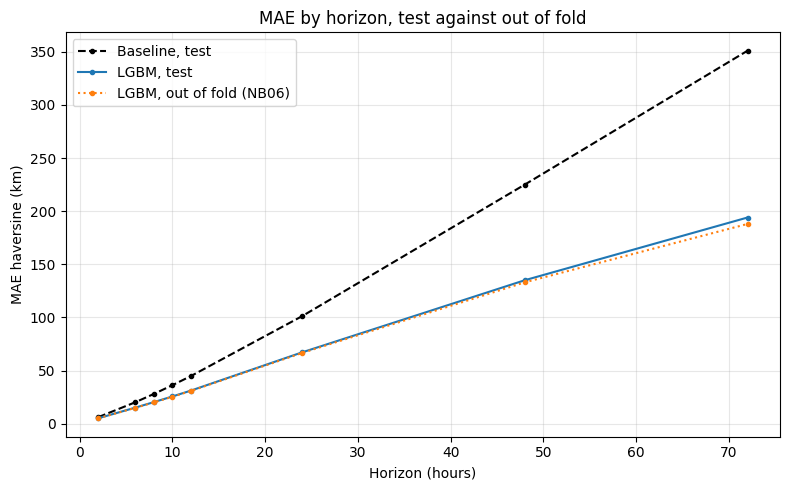

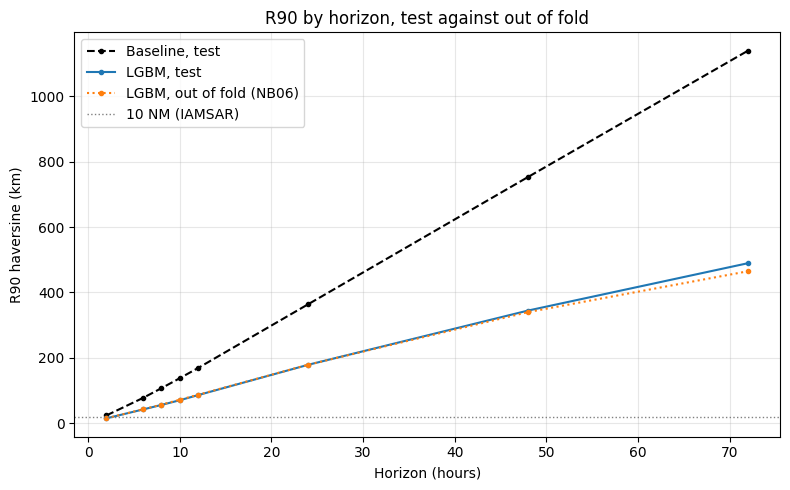

In [14]:
oof_ref = pd.read_csv(Path("outputs") / "lgbm_feature_sets_12h.csv")
oof_lgbm = oof_ref[oof_ref["feature_set"] == "lags_dxdy_geom"].set_index("horizon_hours")
oof_baseline = oof_ref[oof_ref["feature_set"] == "baseline"].set_index("horizon_hours")

test_lgbm = summary_test[summary_test["model_name"] == "lgbm"].set_index("horizon_hours")
test_baseline = summary_test[summary_test["model_name"] == "baseline"].set_index("horizon_hours")

oof_vs_test = pd.DataFrame({
    "lgbm_oof_mae": oof_lgbm["mae_mean"],
    "lgbm_test_mae": test_lgbm["mae_mean"],
    "lgbm_oof_r90": oof_lgbm["r90_km"],
    "lgbm_test_r90": test_lgbm["r90_km"],
    "baseline_oof_mae": oof_baseline["mae_mean"],
    "baseline_test_mae": test_baseline["mae_mean"],
    "baseline_oof_r90": oof_baseline["r90_km"],
    "baseline_test_r90": test_baseline["r90_km"],
}).sort_index()

for predictor in ("lgbm", "baseline"):
    for metric in ("mae", "r90"):
        oof_col = f"{predictor}_oof_{metric}"
        test_col = f"{predictor}_test_{metric}"
        oof_vs_test[f"{predictor}_{metric}_gap_pct"] = (
            (oof_vs_test[test_col] - oof_vs_test[oof_col]) / oof_vs_test[oof_col] * 100
        )

display(oof_vs_test.round(2))

for metric, ylabel in (("mae", "MAE haversine (km)"), ("r90", "R90 haversine (km)")):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(oof_vs_test.index, oof_vs_test[f"baseline_test_{metric}"],
            "k--", marker="o", markersize=3, label="Baseline, test")
    ax.plot(oof_vs_test.index, oof_vs_test[f"lgbm_test_{metric}"],
            "-", color="tab:blue", marker="o", markersize=3, label="LGBM, test")
    ax.plot(oof_vs_test.index, oof_vs_test[f"lgbm_oof_{metric}"],
            ":", color="tab:orange", marker="o", markersize=3, label="LGBM, out of fold (NB06)")
    if metric == "r90":
        ax.axhline(18.52, color="gray", linestyle=":", linewidth=1, label="10 NM (IAMSAR)")
    ax.set_xlabel("Horizon (hours)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel.split(' haversine')[0]} by horizon, test against out of fold")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

- **Generalisation holds.** LGBM's OOF→test gap is at most 3.2 percent on MAE and 5.3 percent on R90, in the same range as the baseline's own drift (2.4 to 3.8 percent). The baseline has no parameters to fit, so its gap is pure sampling difference between the NB06 validation folds and this test set. LGBM moving by a similar amount is evidence against overfitting to trainval, not proof by itself.



### 4.3 Error distribution

Aggregate radii give one number per horizon. The cumulative distribution shows where in the population the difference between the two predictors accumulates.

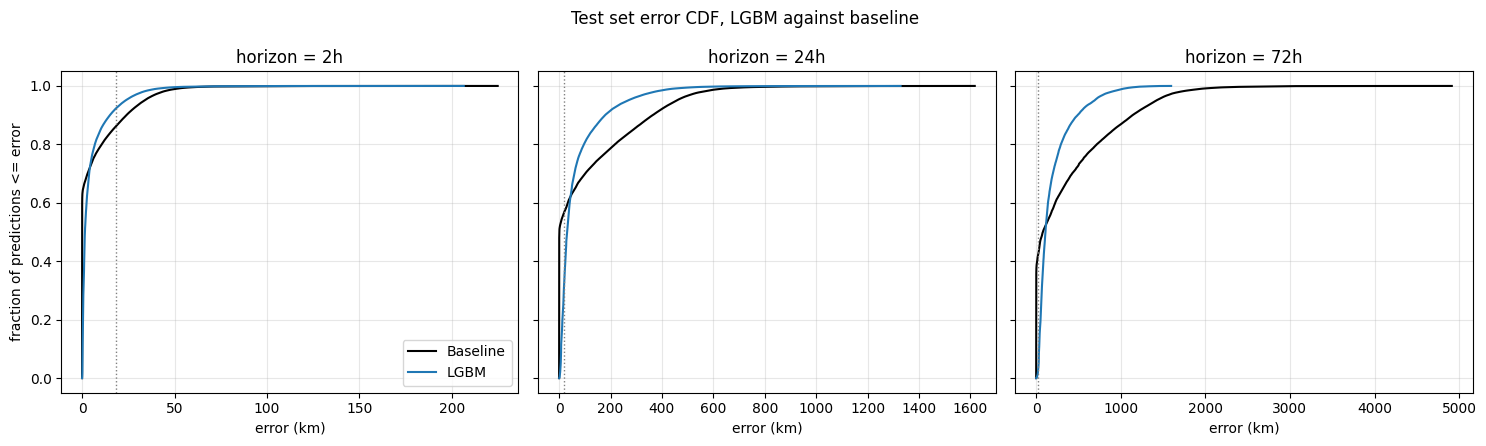

In [15]:
cdf_horizons = [2, 24, 72]
fig, axes = plt.subplots(1, len(cdf_horizons), figsize=(15, 4.5), sharey=True)

for ax, horizon in zip(axes, cdf_horizons):
    subset = results[results["horizon_hours"] == horizon]
    for source, label, color in (("baseline", "Baseline", "black"), ("lgbm", "LGBM", "tab:blue")):
        errors = np.sort(subset[f"error_km_{source}"].to_numpy())
        cdf = np.arange(1, len(errors) + 1) / len(errors)
        ax.plot(errors, cdf, color=color, label=label)
    ax.axvline(18.52, color="gray", linestyle=":", linewidth=1)
    ax.set_xlabel("error (km)")
    ax.set_title(f"horizon = {horizon}h")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("fraction of predictions <= error")
axes[0].legend()
fig.suptitle("Test set error CDF, LGBM against baseline")
plt.tight_layout()
plt.show()

Results are consistent with what was observed during cross-validation.

- **Low end:** the baseline's curve rises sharply near zero error, a mass of near-exact cases LGBM's curve does not match as closely. That mass is what keeps the baseline's pooled R50 below LGBM's in section 4.1 (section 5 breaks down which cases make it up).

- **LGBM compresses the rest of the distribution, and the extreme tail most of all.** From the mid-range up, LGBM's curve is left of the baseline's at every percentile, and the gap widens toward the tail. At 72h, LGBM's worst observed error (1595 km) is a third of the baseline's (4914 km), and its 95th percentile (688 km) is below the baseline's 90th (1139 km, section 4.1). 

- **The crossover between the two curves drops with horizon, so the baseline's edge fades on longer runs.** The curves cross around the 72nd percentile at 2h, the 62nd at 24h, and the 53rd at 72h.


A quick look at `results` and the tail quantiles behind the paragraph above.


In [16]:
results.head(0)

,MMSI,h,LAT_lag_0,LON_lag_0,vx_true,vy_true,effective_speed_knots,straightness,path_length_km,horizon_hours,...,vx_baseline,vy_baseline,LON_true,LAT_true,LON_lgbm,LAT_lgbm,LON_baseline,LAT_baseline,error_km_lgbm,error_km_baseline


In [17]:
results[results["h"] == 4320]["error_km_lgbm"].quantile([0.95, 0.99, 0.999, 1.0])

0.950     688.164238
0.990    1021.867128
0.999    1357.714916
1.000    1595.493817
Name: error_km_lgbm, dtype: float64

In [18]:
results[results["h"] == 4320]["error_km_baseline"].quantile([0.95, 0.99, 0.999, 1.0])

0.950    1419.092191
0.990    1940.949545
0.999    2856.817481
1.000    4913.678356
Name: error_km_baseline, dtype: float64

## 5. Stratified error analysis

We then try to determine whether the tracks yielding high prediction error and low prediction error can be distinguished, in which case we may be able to further improve prediction on high error tracks. 

### 5.1 Regimes

Three classes, defined on the past window only.

- A vessel that barely moved is called stationary. Straightness is unstable when the path length approaches zero, since GPS jitter around a fixed point produces a meaningless ratio, so those cases are separated out before straightness is used at all.

- Among vessels that did move, a high straightness means a near straight run and a low one means a course change inside the window. 

regime
maneuvering     704876
stationary     1793279
straight       1334794
dtype: int64


,regime,horizon_hours,n_cases,mae_baseline,r50_baseline,r90_baseline,mae_lgbm,r50_lgbm,r90_lgbm,baseline_closer_pct
0,maneuvering,2,97481,18.40,14.68,39.33,11.81,7.12,28.89,25.25
1,maneuvering,6,94390,53.53,41.24,115.15,31.54,17.60,79.90,23.40
2,maneuvering,8,92924,70.63,53.42,152.56,40.46,22.07,103.51,22.99
3,maneuvering,10,91603,87.56,65.12,190.30,48.83,26.19,124.97,22.80
4,maneuvering,12,90405,104.23,76.44,227.91,56.90,30.26,145.71,22.45
5,maneuvering,24,85356,200.51,143.06,448.24,99.78,52.90,251.54,22.27
6,maneuvering,48,79964,397.49,282.56,899.32,168.80,98.99,406.06,21.12
7,maneuvering,72,72753,603.65,437.64,1372.68,236.46,146.59,549.54,18.84
8,stationary,2,234131,0.59,0.00,0.10,1.57,0.73,3.01,96.71
9,stationary,6,233191,3.69,0.00,0.95,6.25,2.67,10.53,93.04


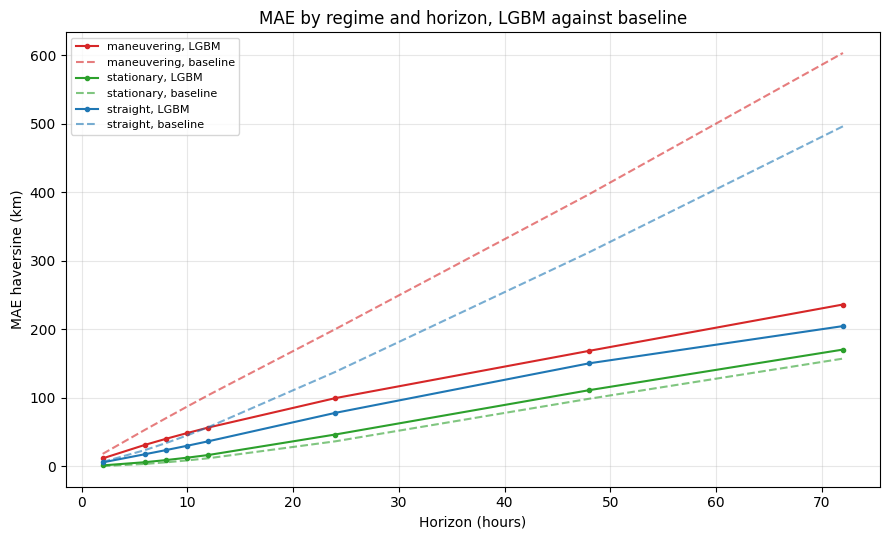

In [19]:
# 0.3 knots over the lookback, expressed as a path length, so that jitter around a
# fixed point does not register as movement. 1.852 converts knots to km/h.
STATIONARY_SPEED_KN = 0.3
STRAIGHT_CUT = 0.95
stationary_path_km = STATIONARY_SPEED_KN * 1.852 * lookback

#labelling tracks as stationary, straight of manoeyvering
results["regime"] = np.where(
    results["path_length_km"] < stationary_path_km, "stationary",
    np.where(results["straightness"] >= STRAIGHT_CUT, "straight", "maneuvering"),
) # np.where(condition, value if true, value if false)
print(results.groupby("regime").size())

def summarise(df, group_cols):
    """MAE, R50 and R90 for both predictors, plus the share of cases where the
    baseline is closer than the model.

    Parameters
    ----------
    df : DataFrame
        Any subset of results.
    group_cols : list
        Columns to group by, for example ["regime", "horizon_hours"].

    Returns
    -------
    DataFrame
        One row per group, with n_cases and one column per metric and predictor.
    """
    rows = []
    for keys, grp in df.groupby(group_cols): #groups corresponding to the keys values for the gien group_cols
        keys = keys if isinstance(keys, tuple) else (keys,)
        row = dict(zip(group_cols, keys))
        row["n_cases"] = len(grp)
        for source in ("baseline", "lgbm"):
            errors = grp[f"error_km_{source}"]
            row[f"mae_{source}"] = errors.mean()
            row[f"r50_{source}"] = errors.quantile(0.50)
            row[f"r90_{source}"] = errors.quantile(0.90)
        row["baseline_closer_pct"] = (
            (grp["error_km_baseline"] < grp["error_km_lgbm"]).mean() * 100
        )
        rows.append(row)
    return pd.DataFrame(rows)

regime_summary = summarise(results, ["regime", "horizon_hours"])
display(regime_summary.round(2))

fig, ax = plt.subplots(figsize=(9, 5.5))
regime_colors = {"stationary": "tab:green", "straight": "tab:blue", "maneuvering": "tab:red"}
for regime, grp in regime_summary.groupby("regime"):
    grp = grp.sort_values("horizon_hours")
    ax.plot(grp["horizon_hours"], grp["mae_lgbm"], "-", marker="o", markersize=3,
            color=regime_colors[regime], label=f"{regime}, LGBM")
    ax.plot(grp["horizon_hours"], grp["mae_baseline"], "--", alpha=0.6,
            color=regime_colors[regime], label=f"{regime}, baseline")
ax.set_xlabel("Horizon (hours)")
ax.set_ylabel("MAE haversine (km)")
ax.set_title("MAE by regime and horizon, LGBM against baseline")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- **Stationary dominates the population.** 47 percent of test cases are stationary, against 35 percent straight and 18 percent maneuvering.

- **The baseline is strongest there, but that edge erodes with horizon.** It is closer to the true position than LGBM on 97 percent of stationary cases at 2h, down to 71 percent at 72h. This regime alone, close to half the population, is what makes the pooled R50 in section 4.1 favour the baseline.

- **On straight and maneuvering cases, LGBM leads on both MAE and R90 at every horizon, and the gap widens with it.** On maneuvering cases MAE goes from 18 km (baseline) against 12 km (LGBM) at 2h, to 604 km against 236 km at 72h.


### 5.2 Straightness

We'll assess whether the prediction error depends on straightness and whether we can route inference to baseline or LGBM based on straightness

Stationary cases are excluded here, their straightness is not meaningful.


,horizon_hours,straightness_bin,n_cases,mae_baseline,r50_baseline,r90_baseline,mae_lgbm,r50_lgbm,r90_lgbm,baseline_closer_pct
0,2,"(-1e-08, 0.68562893]",26948,12.71,5.71,35.63,11.46,4.93,31.99,45.75
1,2,"(0.68562893, 0.86333379]",27794,19.32,16.07,40.10,11.75,6.20,29.48,18.93
2,2,"(0.86333379, 0.92892863]",29255,21.02,19.27,39.93,12.10,9.19,27.30,16.09
3,2,"(0.92892863, 0.9693264]",29432,21.69,20.17,39.39,11.87,8.98,26.39,18.73
4,2,"(0.9693264, 0.99316264]",29586,17.43,14.12,35.77,10.96,8.07,23.91,29.23
5,2,"(0.99316264, 0.99997778]",30878,9.51,4.68,26.33,9.54,6.86,20.06,58.26
6,2,"(0.99997778, 0.9999995]",27641,1.05,0.00,0.00,4.81,3.47,9.22,95.47
7,2,"(0.9999995, 0.99999993]",26725,0.35,0.00,0.00,2.30,1.59,4.22,98.76
8,2,"(0.99999993, 0.99999998]",26122,0.33,0.00,0.00,1.77,1.23,3.25,98.82
9,2,"(0.99999998, 1.0]",26217,0.25,0.00,0.00,1.69,1.00,4.12,99.05


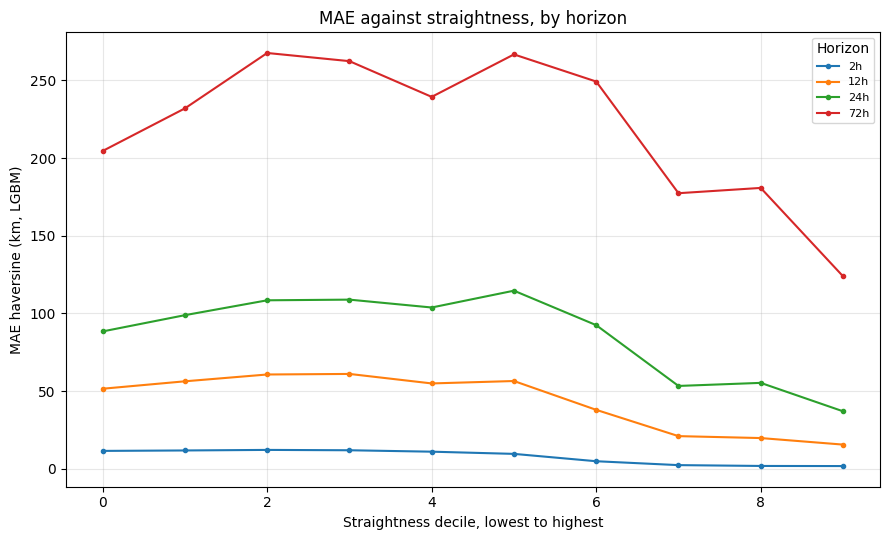

In [20]:
probe_horizons = [2, 12, 24, 72]
moving = results[results["regime"] != "stationary"].copy()
moving["straightness_bin"] = pd.qcut(moving["straightness"], 10, duplicates="drop")

straightness_summary = summarise(
    moving[moving["horizon_hours"].isin(probe_horizons)],
    ["horizon_hours", "straightness_bin"],
)
display(straightness_summary.round(2))

fig, ax = plt.subplots(figsize=(9, 5.5))
for horizon, grp in straightness_summary.groupby("horizon_hours"):
    grp = grp.sort_values("straightness_bin")
    ax.plot(range(len(grp)), grp["mae_lgbm"], "-", marker="o", markersize=3, label=f"{horizon}h")
ax.set_xlabel("Straightness decile, lowest to highest")
ax.set_ylabel("MAE haversine (km, LGBM)")
ax.set_title("MAE against straightness, by horizon")
ax.legend(title="Horizon", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- **MAE vs straightness is not monotone, and there is no stable cutoff.** Across the four horizons the curve rises through the mid-deciles then falls. A single straightness threshold cannot separate hard from easy tracks, nor route between baseline and LGBM.

- **Error does drop in the highest deciles**, where straightness is compressed against 1 and tracks are effectively rectilinear. However it is not enough to build a routing rule: the relationship remains irregular before those last bins, and the location of the peak shifts with horizon. 

### 5.3 Effective speed

We'll also check whether effetive speed is a good proxy for the error in prediction. If it is, then we could anticipate that a given track is hard to predict.

Spearman between effective speed and LGBM error, per case:
   2h: rho = 0.624  (n = 514,729)
   6h: rho = 0.571  (n = 507,449)
   8h: rho = 0.544  (n = 503,832)
  10h: rho = 0.521  (n = 500,227)
  12h: rho = 0.499  (n = 496,649)
  24h: rho = 0.375  (n = 475,751)
  48h: rho = 0.261  (n = 436,031)
  72h: rho = 0.199  (n = 398,281)

effective_speed_knots decile edges: [0.0000e+00 6.0000e-03 1.4000e-02 3.8000e-02 1.4800e-01 3.6500e-01
 8.5900e-01 2.1210e+00 5.9210e+00 1.1254e+01 3.7087e+01]


,horizon_hours,speed_bin,n_cases,mae_baseline,r50_baseline,r90_baseline,mae_lgbm,r50_lgbm,r90_lgbm,baseline_closer_pct
0,2,"(-0.00099785, 0.00561]",50192,0.31,0.00,0.00,1.52,0.88,3.23,98.37
1,2,"(0.00561, 0.0136]",50359,0.39,0.00,0.01,1.57,0.81,3.25,97.78
2,2,"(0.0136, 0.0378]",50404,0.57,0.00,0.07,1.39,0.57,2.54,96.74
3,2,"(0.0378, 0.148]",49814,0.86,0.03,0.25,1.62,0.75,2.32,95.65
4,2,"(0.148, 0.365]",49162,0.92,0.00,0.50,1.92,1.00,3.32,94.46
5,2,"(0.365, 0.859]",49452,1.86,0.00,2.29,2.75,1.19,4.20,87.89
6,2,"(0.859, 2.121]",50371,4.79,0.00,11.89,4.71,1.91,11.48,68.04
7,2,"(2.121, 5.921]",51490,12.94,9.58,33.12,9.64,5.04,25.74,43.19
8,2,"(5.921, 11.254]",53343,17.49,17.40,34.15,11.03,7.69,24.69,34.10
9,2,"(11.254, 37.087]",60142,17.44,12.06,42.39,12.49,8.74,25.93,42.95


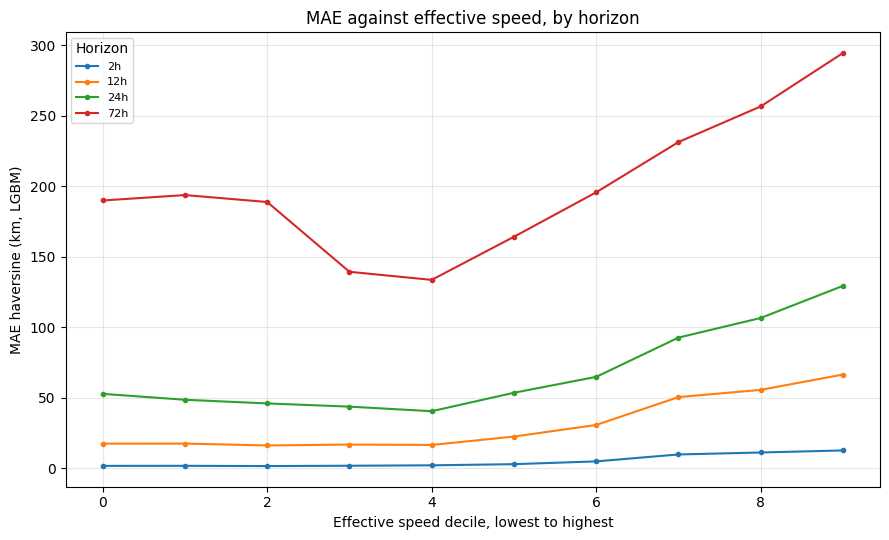

In [21]:
# Effective speed is defined for every case, including stationary ones, unlike
# straightness. Section 5.2 had to drop stationary cases, this one does not, and
# at inference no case can be excluded either.
print("Spearman between effective speed and LGBM error, per case:")
for horizon in horizons_hours:
    subset = results[results["horizon_hours"] == horizon]
    rho, _ = spearmanr(subset["effective_speed_knots"], subset["error_km_lgbm"])
    print(f"  {horizon:>2}h: rho = {rho:.3f}  (n = {len(subset):,})")

results["speed_bin"], speed_edges = pd.qcut(
    results["effective_speed_knots"], 10, retbins=True, duplicates="drop"
)
print("\neffective_speed_knots decile edges:", np.round(speed_edges, 3))

speed_summary = summarise(
    results[results["horizon_hours"].isin(probe_horizons)],
    ["horizon_hours", "speed_bin"],
)
display(speed_summary.round(2))

fig, ax = plt.subplots(figsize=(9, 5.5))
for horizon, grp in speed_summary.groupby("horizon_hours"):
    grp = grp.sort_values("speed_bin")
    ax.plot(range(len(grp)), grp["mae_lgbm"], "-", marker="o", markersize=3, label=f"{horizon}h")
ax.set_xlabel("Effective speed decile, lowest to highest")
ax.set_ylabel("MAE haversine (km, LGBM)")
ax.set_title("MAE against effective speed, by horizon")
ax.legend(title="Horizon", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Rank correlation between effective speed and LGBM error falls from 0.62 at 2h to 0.20 at 72h, but that decline is misleading: Spearman only picks up monotone relations, and at 72h the true shape is a U. MAE by speed decile is high at the slowest deciles (190, 194, 189 km), dips to a trough around deciles 4-5 (139, 133 km), then rises again at the fastest (294 km). 


## 6. Per-vessel analysis

This section analyzes by vessel, to test whether some vessels are intrinsically harder to predict.

Per-vessel MAE is noisy when a vessel contributes few cases, so vessels below a minimum count are excluded.

### 6.1 Distribution of per-vessel MAE

The cumulative distributio of MAE per vessel at 24h, restricted to vessels with at least 50 test cases.


vessels kept: 277 | dropped: 8


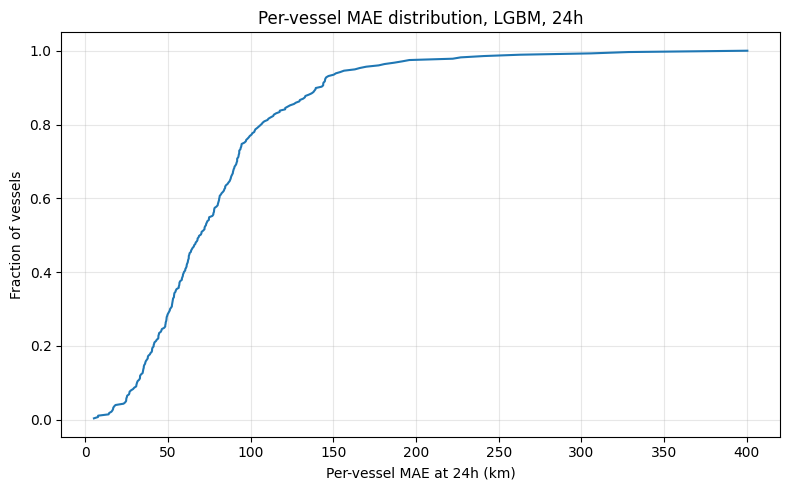

median: 69.9 km | p90: 140.8 km | max: 400.3 km


In [22]:
MIN_CASES_PER_VESSEL = 50
REFERENCE_HORIZON = 24

reference = results[results["horizon_hours"] == REFERENCE_HORIZON]
vessel_mae = reference.groupby("MMSI")["error_km_lgbm"].agg(mae="mean", n_cases="size")
kept_vessels = vessel_mae[vessel_mae["n_cases"] >= MIN_CASES_PER_VESSEL]
print(f"vessels kept: {len(kept_vessels):,} | dropped: {len(vessel_mae) - len(kept_vessels):,}")

sorted_mae = np.sort(kept_vessels["mae"].to_numpy())
ecdf = np.arange(1, len(sorted_mae) + 1) / len(sorted_mae)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sorted_mae, ecdf, color="tab:blue")
ax.set_xlabel(f"Per-vessel MAE at {REFERENCE_HORIZON}h (km)")
ax.set_ylabel("Fraction of vessels")
ax.set_title(f"Per-vessel MAE distribution, LGBM, {REFERENCE_HORIZON}h")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"median: {np.median(sorted_mae):.1f} km | "
      f"p90: {np.percentile(sorted_mae, 90):.1f} km | "
      f"max: {sorted_mae.max():.1f} km")

277 of 285 vessels are kept. The distribution is right-skewed, with no separate cluster of catastrophic vessels: median MAE is 69.9 km, the 90th percentile is 140.8 km, about twice the median, and the single worst vessel reaches 400.3 km. Error increases gradually across the fleet.


### 6.2 Is difficulty a property of the vessel?

We'll assess whether vessels with high prediction error at low horizon also have a high prediction error a high horizon. 

Spearman rho between 2h and 72h per-vessel MAE: 0.719 (p=7.79e-41, n=249)


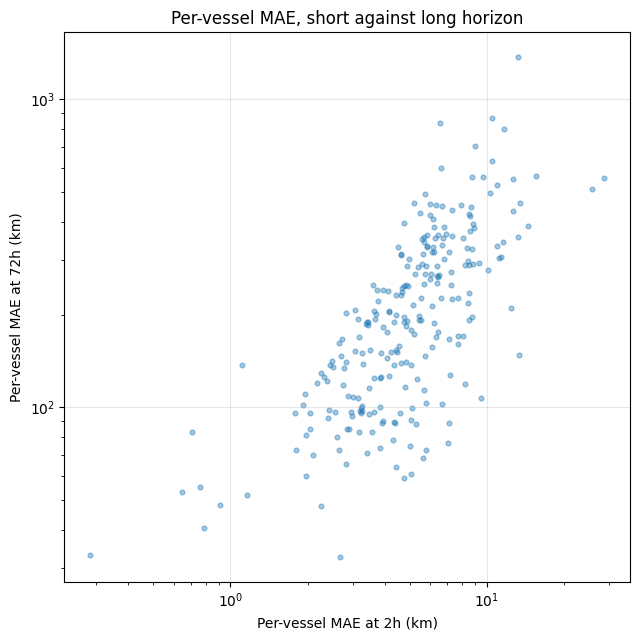

In [23]:
short_horizon = min(horizons_hours)
long_horizon = max(horizons_hours)

def vessel_mae_at(horizon):
    subset = results[results["horizon_hours"] == horizon]
    return subset.groupby("MMSI")["error_km_lgbm"].mean()

paired = pd.concat(
    [vessel_mae_at(short_horizon).rename("mae_short"),
     vessel_mae_at(long_horizon).rename("mae_long")],
    axis=1, join="inner",
)
paired = paired.loc[paired.index.intersection(kept_vessels.index)]

rho, pvalue = spearmanr(paired["mae_short"], paired["mae_long"])
print(f"Spearman rho between {short_horizon}h and {long_horizon}h per-vessel MAE: "
      f"{rho:.3f} (p={pvalue:.2e}, n={len(paired):,})")

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(paired["mae_short"], paired["mae_long"], alpha=0.4, s=12)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(f"Per-vessel MAE at {short_horizon}h (km)")
ax.set_ylabel(f"Per-vessel MAE at {long_horizon}h (km)")
ax.set_title("Per-vessel MAE, short against long horizon")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Spearman rho is 0.72 between per-vessel MAE at 2h and at 72h, the same vessels tend to rank similarly at both ends of the horizon range. This suggests that some vessels are intrinsically harder to predict than others. 


### 6.3 What do the hardest vessels look like?

Mean effective speed, straightness, regime shares and case count for the worst and best deciles of vessels by MAE at 24h.


In [24]:
decile_size = len(kept_vessels) // 10
ranked = kept_vessels.sort_values("mae")
best_mmsi = ranked.index[:decile_size]
worst_mmsi = ranked.index[-decile_size:]

def vessel_profile(mmsi_list, label):
    subset = reference[reference["MMSI"].isin(mmsi_list)]
    return {
        "group": label,
        "mean_mae_km": kept_vessels.loc[mmsi_list, "mae"].mean(),
        "mean_effective_speed_knots": subset["effective_speed_knots"].mean(),
        "mean_straightness": subset["straightness"].mean(),
        "stationary_share_pct": (subset["regime"] == "stationary").mean() * 100,
        "maneuvering_share_pct": (subset["regime"] == "maneuvering").mean() * 100,
        "mean_n_cases": kept_vessels.loc[mmsi_list, "n_cases"].mean(),
    }

profile = pd.DataFrame([
    vessel_profile(worst_mmsi, "worst decile"),
    vessel_profile(best_mmsi, "best decile"),
])
display(profile.round(2))

,group,mean_mae_km,mean_effective_speed_knots,mean_straightness,stationary_share_pct,maneuvering_share_pct,mean_n_cases
0,worst decile,192.27,7.64,0.91,14.40,26.75,815.44
1,best decile,21.58,0.54,0.50,72.41,9.67,2354.41


- The worst decile of vessels averages 7.6 knots and 27 percent maneuvering cases; the best decile averages 0.5 knots and is mostly stationary (72 percent of cases).

- Straightness is not useful here: a vessel that barely moves accumulates GPS jitter without net displacement, so straightness carries no usable signal at the vessel level.

- Effective speed's relationship with error is a U, not a straight line (section 5.3), so it cannot serve as a difficulty score either. It stays useful as a binning variable: section 7 reuses the same speed deciles to build the uncertainty radius lookup table.

## 7. Conditional uncertainty radius

R(p, h) as reported so far is marginal. It states that 90 percent of all prediction cases fall within R90 of the predicted point, pooled over every vessel and every situation. 

However, we showed in this notebook that different ships are easier or harder to predict. So having one single R(p,h) is misleading and leads to over- or under-confidence. 

We also saw that effective speed deciles were associated with different level of prediction error, especially at high horizons. 

This section tests whether conditioning the radius on effective speed produces a usable lookup table, built on held-out data and verified on data it never saw.

The split is the one already in place. The model is refit on `train` alone, its residuals on `val` build the table, and coverage is measured on `test`. Bin edges come from `val` as well, so `test` takes no part in its own calibration.



In [25]:
# train and val are extracted from trainval_long by MMSI. Every feature is
# computed within a vessel, so slicing after the fact gives the same result as
# rebuilding each subset from scratch, without a second preprocessing pass.
train_mmsi = set(df_train["MMSI"].unique())
is_train = trainval_long["MMSI"].isin(train_mmsi)

calibration_model = LGBMRegressor(verbose=-1, random_state=settings.random_seed)
calibration_out = fit_predict(
    trainval_long.loc[is_train, final_feature_cols],
    trainval_long.loc[is_train, ["vx", "vy"]],
    trainval_long.loc[~is_train, final_feature_cols],
    calibration_model,
)

calibration = trainval_long.loc[
    ~is_train, ["MMSI", "h", "LAT_lag_0", "LON_lag_0", "vx", "vy", "effective_speed_knots"]
].copy()
calibration["horizon_hours"] = (calibration["h"] / 60).round().astype(int)
calibration["vx_pred"] = calibration_out["vx_pred"]
calibration["vy_pred"] = calibration_out["vy_pred"]

LON_pred = calibration["LON_lag_0"] + calibration["vx_pred"] * calibration["h"]
LAT_pred = calibration["LAT_lag_0"] + calibration["vy_pred"] * calibration["h"]
LON_true = calibration["LON_lag_0"] + calibration["vx"] * calibration["h"]
LAT_true = calibration["LAT_lag_0"] + calibration["vy"] * calibration["h"]
calibration["error_km"] = haversine_distance(
    LAT_true.to_numpy(), LON_true.to_numpy(), LAT_pred.to_numpy(), LON_pred.to_numpy()
)

print(f"calibration set: {len(calibration):,} rows, "
      f"{calibration['MMSI'].nunique():,} vessels")

calibration set: 3,893,021 rows, 308 vessels


The calibration set holds 308 vessels the calibration model never trained on. The lookup table below is built entirely from their residuals.


In [26]:
# Bin edges from the calibration set only. 
# caculated the decile 
_, calibration_edges = pd.qcut(
    calibration["effective_speed_knots"], 10, retbins=True, duplicates="drop"
)
calibration_edges[0] = -np.inf # The outer edges are opened so that a
# test case faster or slower than anything seen in calibration still lands in a bin.
calibration_edges[-1] = np.inf

#reassign lines from the calibration dataset to speed bins
#val set
calibration["speed_bin_calib"] = pd.cut(calibration["effective_speed_knots"], bins=calibration_edges)

#test set
results["speed_bin_calib"] = pd.cut(results["effective_speed_knots"], bins=calibration_edges)

# The lookup table itself, one radius per speed bin and horizon.
#calculate R90 for each (bin, horizon) couple
radius_lookup = (
    calibration.groupby(["speed_bin_calib", "horizon_hours"], observed=True)["error_km"]
    .quantile(0.90)
    .rename("r90_conditional_km")
)
#R90 for the entire population
radius_marginal = (
    calibration.groupby("horizon_hours")["error_km"].quantile(0.90)
)

print("Conditional R90 lookup table, built on the calibration set (km):")
display(radius_lookup.unstack().round(1))
print("Marginal R90 for reference (km):")
display(radius_marginal.round(1))

Conditional R90 lookup table, built on the calibration set (km):


horizon_hours,2,6,8,10,12,24,48,72
speed_bin_calib,,,,,,,,
"(-inf, 0.00518]",3.1,11.8,16.9,22.2,28.8,103.5,297.3,454.3
"(0.00518, 0.0111]",3.9,11.9,16.0,21.3,27.9,116.4,333.4,471.7
"(0.0111, 0.0263]",3.7,12.3,19.0,27.7,35.3,114.3,283.2,485.5
"(0.0263, 0.0724]",2.8,13.4,20.8,26.1,31.6,93.9,230.2,351.2
"(0.0724, 0.27]",3.1,11.1,16.1,22.5,31.3,83.3,199.9,274.2
"(0.27, 0.774]",4.5,16.3,23.2,32.0,41.1,117.5,228.1,364.4
"(0.774, 1.963]",12.5,40.2,52.6,66.0,78.4,158.9,319.3,422.9
"(1.963, 5.001]",23.4,62.9,80.9,98.0,115.3,211.4,358.2,473.9
"(5.001, 10.883]",24.7,67.3,88.7,109.8,129.4,242.1,392.2,485.7


Marginal R90 for reference (km):


horizon_hours
2      14.9
6      42.1
8      56.0
10     69.8
12     84.4
24    169.2
48    322.8
72    446.0
Name: error_km, dtype: float64

In [27]:
# Coverage on the test set: what share of cases actually falls inside the radius

# The marginal radius is measured the same way, for comparison.
lookup_dict = radius_lookup.to_dict()

coverage_rows = []
for (speed_bin, horizon), grp in results.groupby(["speed_bin_calib", "horizon_hours"], observed=True):
    r90_conditional = lookup_dict.get((speed_bin, horizon))
    if r90_conditional is None:
        continue
    r90_marginal = radius_marginal[horizon]
    coverage_rows.append({
        "speed_bin": speed_bin,
        "horizon_hours": horizon,
        "n_test": len(grp),
        "r90_conditional_km": r90_conditional,
        "coverage_conditional_pct": (grp["error_km_lgbm"] <= r90_conditional).mean() * 100,
        "r90_marginal_km": r90_marginal,
        "coverage_marginal_pct": (grp["error_km_lgbm"] <= r90_marginal).mean() * 100,
    })

coverage = pd.DataFrame(coverage_rows)
display(coverage.round(2))

del calibration
_ = gc.collect()


,speed_bin,horizon_hours,n_test,r90_conditional_km,coverage_conditional_pct,r90_marginal_km,coverage_marginal_pct
0,"(-inf, 0.00518]",2,44053,3.06,87.89,14.92,99.19
1,"(-inf, 0.00518]",6,43902,11.81,91.83,42.14,97.35
2,"(-inf, 0.00518]",8,43800,16.91,90.87,55.95,96.70
3,"(-inf, 0.00518]",10,43689,22.21,89.82,69.82,96.15
4,"(-inf, 0.00518]",12,43551,28.82,89.34,84.36,95.66
...,...,...,...,...,...,...,...
75,"(10.883, inf]",10,59854,105.87,88.62,69.82,76.99
76,"(10.883, inf]",12,58358,126.59,88.95,84.36,77.03
77,"(10.883, inf]",24,49977,247.39,89.56,169.21,77.64
78,"(10.883, inf]",48,37660,409.25,87.09,322.85,78.30


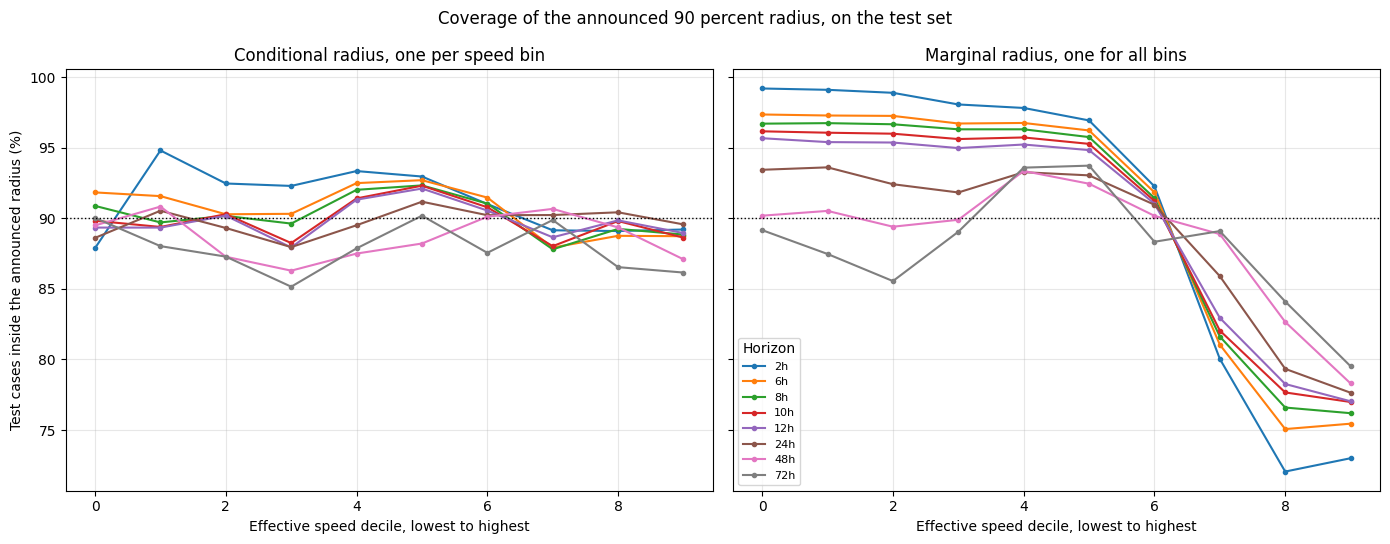

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
for ax, column, title in (
    (axes[0], "coverage_conditional_pct", "Conditional radius, one per speed bin"),
    (axes[1], "coverage_marginal_pct", "Marginal radius, one for all bins"),
):
    for horizon, grp in coverage.groupby("horizon_hours"):
        grp = grp.sort_values("speed_bin")
        ax.plot(range(len(grp)), grp[column], "-", marker="o", markersize=3, label=f"{horizon}h")
    ax.axhline(90, color="black", linestyle=":", linewidth=1)
    ax.set_xlabel("Effective speed decile, lowest to highest")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Test cases inside the announced radius (%)")
axes[1].legend(title="Horizon", fontsize=8)
fig.suptitle("Coverage of the announced 90 percent radius, on the test set")
plt.tight_layout()
plt.show()

- **The marginal radius' miscalibration depends on speed bin, not on horizon.** At every horizon it over-covers slow vessels (more margin than needed) and under-covers fast ones (less margin than needed) at the same time.

- **At 2h, the gap is 26 points**: the slowest bin's announced 90 percent coverage is really 99 percent, the fastest bin's is only 73 percent. The fast-vessel side is the one that matters most, since a wrong radius there is most likely to send a search to the wrong place.

- **The gap narrows with horizon but does not close.** At 72h the fastest bin is still under-covered at 79.5 percent.

- **Conditioning the radius on effective speed improves the R90 calibration.** Every bin, at every horizon, lands close to 90 percent (the fastest bin at 72h goes from 79.5 to 86.2 percent).

- section 5.3 found effective speed tied to error only through a non-monotone, U-shaped relation, too irregular for a single threshold or correction term, but exactly the shape a binned lookup table is built to absorb.


## 8. Conclusion

**Deliverable.** For any vessel and any horizon from 2h to 72h, the system returns a predicted position together with a speed-conditioned uncertainty radius R(p, h, s) that sizes the search area with calibrated confidence. A bare position does not define a search area, so the radius is the operational output.

**Model.** A single LGBM regressor with horizon `h` as a feature, fit once on the full trainval set, one prediction for every horizon. No per-horizon models. The model learns inside that one fit how each feature's relevance shifts with `h` (vessel geometry is irrelevant at 2h and starts mattering at 72h, per NB06).

**Performance.** Against the constant-velocity baseline (12h lookback), lower MAE and lower R90 at every horizon. Search area (πR90²) drops **60.5% at 2h** and **81.5% at 72h**, the relative gain growing with horizon. Against the stronger 3h-lookback baseline (appendix), the model trails only at 2h, where both radii are inside 10 NM.

**Where it makes the difference.** The gain is concentrated on maneuvering vessels and on the tail of the error distribution. On the stationary and straight majority, close to half the fleet, constant-velocity extrapolation is already near exact and keeps the lower R50. The model earns its cost on the hard, high-error cases, which are also the ones that drive the search area.

**Why the radius is conditional.** A pooled R90 is miscalibrated by speed: real coverage is **73% for the fastest vessels at 2h** against an announced 90%, while slow vessels are over-covered. The stratified analysis (regimes, per-vessel difficulty, the speed-to-error relation) is what makes a conditional radius possible.

**Conditional radius R(p, h, s).** Calibrated on a held-out split and checked on the test set, it brings every speed bin close to the announced 90% (the fastest bin at 72h moves from **79.5% to 86.2%**). Coverage is still a few points under 90% at long horizons, a known limit.


## Appendix: baseline at 3h lookback

NB03 found a 3h lookback stronger than 12h for the constant-velocity baseline at short horizons. This appendix recomputes that baseline on the same test set and horizon grid as section 4, so the final LGBM (fit under the project's fixed 12h lookback) can be compared against the stronger baseline as well as the 12h one already reported.

In [29]:
# Appendix: constant-velocity baseline with 3h lookback on df_test.
# Mirrors NB03 section 2 (linear extrapolation). Reuses compute_metrics from section 2.1.
lookback_3h_minutes = 180
l_steps = lookback_3h_minutes // settings.resample_interval_min  # 18

df_test_sorted = df_test.sort_values(["MMSI", "BaseDateTime"]).copy()
baseline_3h_rows = []

for horizon_h in horizons_hours:
    h_steps = horizon_h * 60 // settings.resample_interval_min
    shifted = df_test_sorted.copy()
    shifted["LAT_start"] = df_test_sorted.groupby("MMSI")["LAT"].shift(l_steps)
    shifted["LON_start"] = df_test_sorted.groupby("MMSI")["LON"].shift(l_steps)
    shifted["LAT_target"] = df_test_sorted.groupby("MMSI")["LAT"].shift(-h_steps)
    shifted["LON_target"] = df_test_sorted.groupby("MMSI")["LON"].shift(-h_steps)
    shifted = shifted.dropna(subset=["LAT_start", "LON_start", "LAT_target", "LON_target"])

    velocity_LAT = (shifted["LAT"] - shifted["LAT_start"]) / l_steps
    velocity_LON = (shifted["LON"] - shifted["LON_start"]) / l_steps
    LAT_pred = shifted["LAT"] + velocity_LAT * h_steps
    LON_pred = shifted["LON"] + velocity_LON * h_steps

    error_km = haversine_distance(
        shifted["LAT_target"].to_numpy(),
        shifted["LON_target"].to_numpy(),
        LAT_pred.to_numpy(),
        LON_pred.to_numpy(),
    )
    baseline_3h_rows.append(pd.DataFrame({
        "model_name": "baseline_3h",
        "h": horizon_h * 60,
        "error_km": error_km,
    }))

baseline_3h_errors = pd.concat(baseline_3h_rows, ignore_index=True)
summary_baseline_3h = compute_metrics(baseline_3h_errors)
summary_baseline_3h["horizon_hours"] = (summary_baseline_3h["h"] / 60).round().astype(int)
summary_baseline_3h = summary_baseline_3h.set_index("horizon_hours").sort_index()

print(f"baseline 3h lookback: {len(baseline_3h_errors):,} rows across {len(horizons_hours)} horizons")
display(summary_baseline_3h[["mae_mean", "r50_km", "r90_km"]].round(2))


baseline 3h lookback: 3,964,830 rows across 8 horizons


,mae_mean,r50_km,r90_km
horizon_hours,,,
2,3.55,0.00,13.21
6,14.55,0.00,57.73
8,21.52,0.01,85.39
10,29.22,0.01,115.32
12,37.55,0.02,147.12
24,95.20,0.29,354.88
48,226.55,18.21,782.50
72,363.46,52.91,1229.66


In [30]:
# Comparison: section 4 baseline_12h + LGBM (already computed) vs appendix baseline_3h.
comparison = pd.DataFrame({
    "baseline_12h_mae": mae_test["baseline"],
    "baseline_3h_mae": summary_baseline_3h["mae_mean"].round(2),
    "lgbm_mae": mae_test["lgbm"],
    "baseline_12h_r90": r90_test["baseline"],
    "baseline_3h_r90": summary_baseline_3h["r90_km"].round(2),
    "lgbm_r90": r90_test["lgbm"],
})
comparison["lgbm_area_reduction_pct_vs_baseline_3h"] = (
    (1 - (comparison["lgbm_r90"] / comparison["baseline_3h_r90"]) ** 2) * 100
).round(1)

display(comparison)


,baseline_12h_mae,baseline_3h_mae,lgbm_mae,baseline_12h_r90,baseline_3h_r90,lgbm_r90,lgbm_area_reduction_pct_vs_baseline_3h
horizon_hours,,,,,,,
2,6.09,3.55,5.07,23.98,13.21,15.07,-30.1
6,20.14,14.55,15.08,77.67,57.73,42.31,46.3
8,27.95,21.52,20.26,107.29,85.39,56.09,56.9
10,36.19,29.22,25.59,137.83,115.32,70.42,62.7
12,44.81,37.55,31.13,169.03,147.12,86.14,65.7
24,101.24,95.20,67.15,363.89,354.88,178.74,74.6
48,225.04,226.55,135.01,753.13,782.50,344.65,80.6
72,350.96,363.46,194.00,1139.44,1229.66,489.52,84.2


- Against the stronger **3h-lookback** baseline, LGBM trails only at **2h** (R90 **15.1** vs **13.2** km, both inside 10 NM), then is better from **6h** on with the usual growing margin.
- A 3h-lookback constant-velocity rule being ahead at 2h places the operational switch to LGBM from about **4–6h**.
